# Build Clint GAT model.

This notebook shows how to build an attention-based model (GATv2Conv) to train, predict and evaluate microsomal clint from Chembl data. 

In [1]:
import pandas as pd
import torch
import numpy as np
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Setup.

In [2]:
readout = 'microsomal_clint'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [68]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
df.head(5)

,Unnamed: 0,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,clint,units
0,0,33031,CHEMBL695026,CHEMBL306457,CL,mL.min-1.kg-1,=,47.7,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,47.7,mL.min-1.kg-1
1,1,34270,CHEMBL695026,CHEMBL66457,CL,mL.min-1.kg-1,=,4.9,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,4.9,mL.min-1.kg-1
2,2,34274,CHEMBL695026,CHEMBL304053,CL,mL.min-1.kg-1,=,16.5,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,16.5,mL.min-1.kg-1
3,3,35507,CHEMBL695026,CHEMBL68366,CL,mL.min-1.kg-1,=,8.0,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,8.0,mL.min-1.kg-1
4,13,39099,CHEMBL695026,CHEMBL303673,CL,mL.min-1.kg-1,=,6.1,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,6.1,mL.min-1.kg-1


In [69]:
def clint_log_transform(y, shift=1e-6):
    return np.log10(y + shift)

def clint_inverse_transform(y_log):
    return 10 ** y_log

In [70]:
smiles_list = df['smiles'].tolist()
clint_values = df['clint'].tolist()

Pytorch geometric fix

In [71]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

from torch_geometric.data import Data

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [72]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

## Featurisation step.

In [73]:
# We can get reasonable results (R^2 ~ 0.5) with simple atomic features.
# But as we are trying to predict a more complex phenomena, we can benefit from RdKit 
# descriptors to encode hybridisation, partial charges, etc.
# Clint prediction should improve from here.

from rdkit.Chem import rdPartialCharges, rdMolDescriptors, Descriptors, PeriodicTable

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount
]

# Precompute a dict of electronegativities (Pauling scale)
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

# List of metals by atomic number (common metals)
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (can be scaled later if needed)
    features += [
        atom.GetDegree(),               # n_bonded neighbors
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()

    # Physical properties from periodic table (normalised to 0-1)
    # We could prpbably play with this, if we want to.
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # ~1–200 → 0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # ~0.5–2.5 → 0–1
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # ~0–4 → 0–1
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # Valence electrons, ~0–8
        1.0 if atomic_num in metals else 0.0                  # binary
    ]


    # Partial charge (Gasteiger)
    # Something else we could play with (e.g. AM1-BCC) but this adds cost.
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
            if np.isnan(charge) or np.isinf(charge):
                charge = 0.0
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]
    return np.array(features, dtype=np.float32)


## Convert Featurised molecules into graph for the model.

In [74]:
def mol_to_graph(smiles: str, label: float = None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            val = safe_value(val)
        except:
            val = 0.0
        global_features.append(val)
    global_features = torch.tensor(global_features, dtype=torch.float32)

    # Use MoleculeData class we added here instead of Data
    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    return data


Data loader code.

In [75]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [76]:
from torch_geometric.data import Batch

def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [95]:
from sklearn.preprocessing import StandardScaler

# Step 0: Clean invalid values
cleaned_data = [
    (smi, clint)
    for smi, clint in zip(smiles_list, clint_values)
    if np.isfinite(clint) and clint >= 0  # remove NaN, inf, and negatives
]

print(f"Filtered out {len(smiles_list) - len(cleaned_data)} invalid entries")

# Step 1: Apply log transform
log_clint_values = np.array([clint_log_transform(clint) for _, clint in cleaned_data]).reshape(-1, 1)

# Step 2: Standardize
scaler = StandardScaler()
log_clint_scaled = scaler.fit_transform(log_clint_values).flatten()
assert not np.isnan(log_clint_scaled).any(), "NaN found in standardized labels!" # quick check

# Step 3: Create data list
data_list = []
for (smi, _), label in zip(cleaned_data, log_clint_scaled):
    data = mol_to_graph(smi, label)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

Filtered out 9 invalid entries


## The Regression model definition.

In [96]:
# Use GATv2Conv as the attention should more effectively capture functional groups.

from torch_geometric.nn import GATv2Conv, global_mean_pool

class GATv2Regressor(torch.nn.Module):
    def __init__(self, input_dim, edge_dim, hidden_dim=128, heads=2, global_feat_dim=0):
        super().__init__()

        self.edge_encoder = torch.nn.Linear(edge_dim, hidden_dim)

        self.gat1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.1, edge_dim=hidden_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=0.1, edge_dim=hidden_dim)

        # Adjust input dimension of first linear layer to include global descriptor size
        self.lin = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim + global_feat_dim, hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        device = next(self.parameters()).device
        x, edge_index, edge_attr, batch = x.to(device), edge_index.to(device), edge_attr.to(device), batch.to(device)

        edge_attr = self.edge_encoder(edge_attr)

        x = self.gat1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.gat2(x, edge_index, edge_attr)
        x = F.elu(x)

        x = global_mean_pool(x, batch)  # [batch_size, hidden_dim]

        if hasattr(data, 'global_features'):
            global_features = data.global_features.to(x.device)  # [batch_size, global_feat_dim]
            #print(f"Shape x: {x.shape}, global_features: {global_features.shape}") # Debugging line - commented out unless necessary
            x = torch.cat([x, global_features], dim=1)

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [97]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [98]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        # Clamp predictions to avoid exploding gradients
        out = torch.clamp(out, min=-10.0, max=10.0)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [99]:
def train_with_early_stopping(params):
    model = GATv2Regressor(
        input_dim=params['input_dim'],
        edge_dim=params['edge_dim'],
        hidden_dim=params['hidden_dim'],
        heads=2,
        global_feat_dim=params.get('global_feat_dim', 0)
    )
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.SmoothL1Loss()

    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0

    for epoch in range(10):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if not torch.isnan(torch.tensor(val_loss)) and val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(torch.load('best_model.pth'))
    return model


With hyperparameter tuning.

In [100]:
import itertools

global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': [0.001],
    'hidden_dim': [64, 128],
}

input_dim = data_list[0].x.shape[1]
edge_dim = data_list[0].edge_attr.shape[1]

best_model = None
best_val_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"Training with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'edge_dim': edge_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.SmoothL1Loss(), device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

Training with lr=0.001, hidden_dim=64
Epoch 1 | Train Loss: 0.4478 | Val Loss: 0.4768
Epoch 2 | Train Loss: 0.4408 | Val Loss: 0.4285
Epoch 3 | Train Loss: 0.4281 | Val Loss: 0.4456
Epoch 4 | Train Loss: 0.4326 | Val Loss: 0.4341
Epoch 5 | Train Loss: 0.4265 | Val Loss: 0.4552
Epoch 6 | Train Loss: 0.4247 | Val Loss: 0.4117
Epoch 7 | Train Loss: 0.4209 | Val Loss: 0.4104
Epoch 8 | Train Loss: 0.4240 | Val Loss: 0.4806
Epoch 9 | Train Loss: 0.4243 | Val Loss: 0.4121
Epoch 10 | Train Loss: 0.4198 | Val Loss: 0.4253
Training with lr=0.001, hidden_dim=128
Epoch 1 | Train Loss: 0.6060 | Val Loss: 0.4901
Epoch 2 | Train Loss: 0.4719 | Val Loss: 0.4304
Epoch 3 | Train Loss: 0.4485 | Val Loss: 0.4245
Epoch 4 | Train Loss: 0.4367 | Val Loss: 0.4192
Epoch 5 | Train Loss: 0.4289 | Val Loss: 0.4123
Epoch 6 | Train Loss: 0.4463 | Val Loss: 0.4123
Epoch 7 | Train Loss: 0.4397 | Val Loss: 0.4130
Epoch 8 | Train Loss: 0.4233 | Val Loss: 0.4036
Epoch 9 | Train Loss: 0.4388 | Val Loss: 0.4247
Epoch 10 |

## Evaluation

In [101]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, data_loader, scaler, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            
            # Model outputs predictions in standardized log10(Clint) scale
            pred_scaled = model(batch).cpu().numpy().reshape(-1, 1)
            true_scaled = batch.y.cpu().numpy().reshape(-1, 1)

            # Inverse scale back to log10(Clint)
            pred_log = scaler.inverse_transform(pred_scaled).flatten()
            true_log = scaler.inverse_transform(true_scaled).flatten()

            # Inverse log-transform to get original Clint values
            pred_clint = 10 ** pred_log
            true_clint = 10 ** true_log

            y_pred.extend(pred_clint)
            y_true.extend(true_clint)

    # Calculate regression metrics on original scale
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\nClint RMSE: {rmse:.4f}")
    print(f"Clint MAE: {mae:.4f}")
    print(f"Clint R²: {r2:.4f}")

    return y_true, y_pred

# Usage example:
y_true, y_pred = evaluate_model(best_model, val_loader, scaler, device)


Clint RMSE: 49.2035
Clint MAE: 15.8338
Clint R²: -0.1094


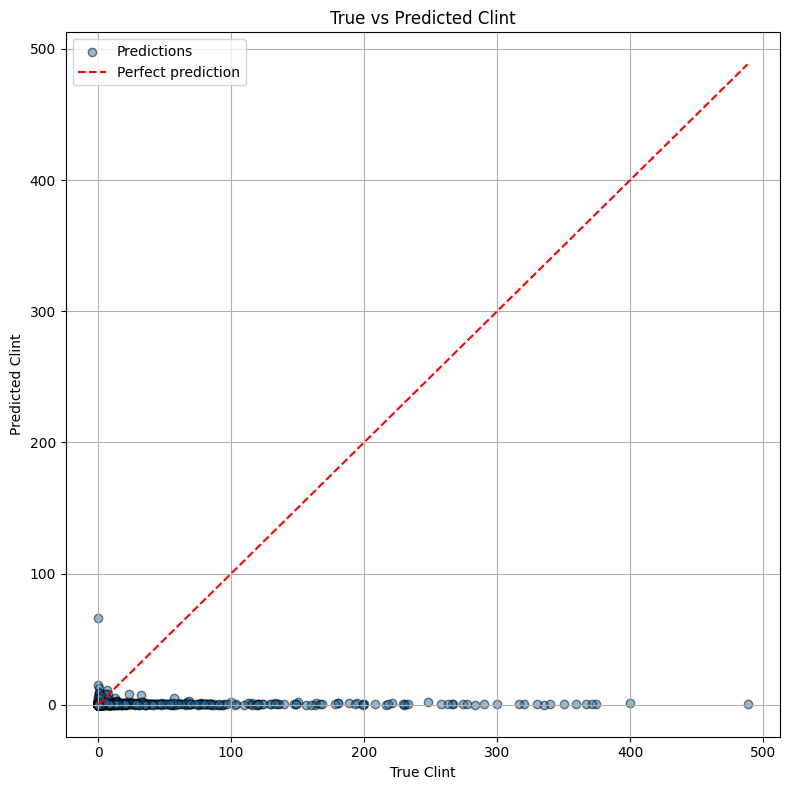

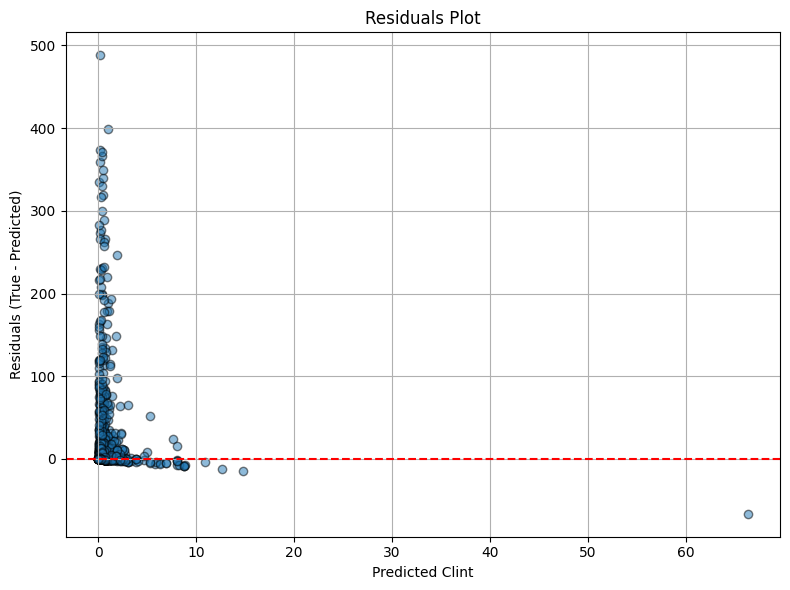

In [102]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(8, 8))
    
    # Scatter plot: True vs Predicted Clint
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolors='k', label='Predictions')
    
    # Plot y=x line for perfect prediction reference
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    plt.xlabel("True Clint")
    plt.ylabel("Predicted Clint")
    plt.title("True vs Predicted Clint")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = np.array(y_true) - np.array(y_pred)
    plt.figure(figsize=(8, 6))
    
    plt.scatter(y_pred, residuals, alpha=0.5, edgecolors='k')
    plt.axhline(0, color='r', linestyle='--')
    
    plt.xlabel("Predicted Clint")
    plt.ylabel("Residuals (True - Predicted)")
    plt.title("Residuals Plot")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Usage example:
plot_predictions(y_true, y_pred)
plot_residuals(y_true, y_pred)


In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "edge_dim": edge_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "clint_gat.pt")